In [1]:
from pathlib import Path
import time
import gc

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

from lightgbm import LGBMClassifier

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
REPORTS_DIR = PROJECT_ROOT / "reports"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data: {DATA_DIR}")
print(f"Interim data: {INTERIM_DIR}")

Project root: c:\Projects\creditlens-ai
Raw data: c:\Projects\creditlens-ai\data\raw
Interim data: c:\Projects\creditlens-ai\data\interim


In [2]:
feature_files = {
    "bureau": INTERIM_DIR / "bureau_customer_features.csv",
    "previous": INTERIM_DIR / "previous_application_customer_features.csv",
    "installments": INTERIM_DIR / "installments_customer_features.csv",
}

for name, path in feature_files.items():
    print(
        f"{name:15} "
        f"exists={path.exists()} "
        f"path={path}"
    )

bureau          exists=True path=c:\Projects\creditlens-ai\data\interim\bureau_customer_features.csv
previous        exists=True path=c:\Projects\creditlens-ai\data\interim\previous_application_customer_features.csv
installments    exists=True path=c:\Projects\creditlens-ai\data\interim\installments_customer_features.csv


In [3]:
application_train = pd.read_csv(
    DATA_DIR / "application_train.csv",
    low_memory=False
)

bureau_features = pd.read_csv(
    feature_files["bureau"]
)

previous_features = pd.read_csv(
    feature_files["previous"]
)

installment_features = pd.read_csv(
    feature_files["installments"]
)

print(f"Application:  {application_train.shape}")
print(f"Bureau:       {bureau_features.shape}")
print(f"Previous:     {previous_features.shape}")
print(f"Installments: {installment_features.shape}")

Application:  (307511, 122)
Bureau:       (305811, 20)
Previous:     (338857, 24)
Installments: (339587, 30)


In [4]:
train_full = (
    application_train
    .merge(
        bureau_features,
        on="SK_ID_CURR",
        how="left",
        validate="one_to_one"
    )
    .merge(
        previous_features,
        on="SK_ID_CURR",
        how="left",
        validate="one_to_one"
    )
    .merge(
        installment_features,
        on="SK_ID_CURR",
        how="left",
        validate="one_to_one"
    )
)

print(f"Full dataset shape: {train_full.shape}")
print(f"Duplicate customers: {train_full['SK_ID_CURR'].duplicated().sum()}")
print(f"Missing TARGET: {train_full['TARGET'].isna().sum()}")

Full dataset shape: (307511, 193)
Duplicate customers: 0
Missing TARGET: 0


In [5]:
train_full["BUREAU_HAS_HISTORY"] = (
    train_full["BUREAU_LOAN_COUNT"]
    .notna()
    .astype("int8")
)

train_full["PREV_HAS_HISTORY"] = (
    train_full["PREV_APPLICATION_COUNT"]
    .notna()
    .astype("int8")
)

train_full["INST_HAS_HISTORY"] = (
    train_full["INST_PAYMENT_RECORD_COUNT"]
    .notna()
    .astype("int8")
)

train_full["DAYS_EMPLOYED_ANOMALY"] = (
    train_full["DAYS_EMPLOYED"] == 365243
).astype("int8")

train_full.loc[
    train_full["DAYS_EMPLOYED"] == 365243,
    "DAYS_EMPLOYED"
] = np.nan

print(f"Dataset shape after engineered flags: {train_full.shape}")

Dataset shape after engineered flags: (307511, 197)


C:\Users\Vıctus\AppData\Local\Temp\ipykernel_3444\4129258819.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_full["BUREAU_HAS_HISTORY"] = (
C:\Users\Vıctus\AppData\Local\Temp\ipykernel_3444\4129258819.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_full["PREV_HAS_HISTORY"] = (
C:\Users\Vıctus\AppData\Local\Temp\ipykernel_3444\4129258819.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all 

In [6]:
y = train_full["TARGET"].copy()

X = train_full.drop(
    columns=[
        "TARGET",
        "SK_ID_CURR"
    ]
).copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Positive class rate: {y.mean() * 100:.2f}%")

X shape: (307511, 195)
y shape: (307511,)
Positive class rate: 8.07%


In [7]:
categorical_columns = (
    X
    .select_dtypes(
        include=["object", "string", "category"]
    )
    .columns
    .tolist()
)

numeric_columns = (
    X
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

for column in categorical_columns:
    X[column] = X[column].astype("category")

print(f"Numeric features: {len(numeric_columns)}")
print(f"Categorical features: {len(categorical_columns)}")
print(
    f"Total features: "
    f"{len(numeric_columns) + len(categorical_columns)}"
)

X[categorical_columns].dtypes.head(10)

Numeric features: 179
Categorical features: 16
Total features: 195


NAME_CONTRACT_TYPE     category
CODE_GENDER            category
FLAG_OWN_CAR           category
FLAG_OWN_REALTY        category
NAME_TYPE_SUITE        category
NAME_INCOME_TYPE       category
NAME_EDUCATION_TYPE    category
NAME_FAMILY_STATUS     category
NAME_HOUSING_TYPE      category
OCCUPATION_TYPE        category
dtype: object

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")

print(
    f"Train positive rate: "
    f"{y_train.mean() * 100:.2f}%"
)

print(
    f"Validation positive rate: "
    f"{y_val.mean() * 100:.2f}%"
)

Train shape: (246008, 195)
Validation shape: (61503, 195)
Train positive rate: 8.07%
Validation positive rate: 8.07%


In [9]:
import lightgbm as lgb

from lightgbm import LGBMClassifier

print(f"LightGBM version: {lgb.__version__}")

LightGBM version: 4.7.0


In [10]:
lightgbm_model = LGBMClassifier(
    objective="binary",

    n_estimators=2000,
    learning_rate=0.03,

    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=0.1,

    class_weight="balanced",

    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lightgbm_model

,learning_rate,0.03
,n_estimators,2000
,objective,'binary'
,class_weight,'balanced'
,min_child_samples,50
,subsample,0.8
,colsample_bytree,0.8
,reg_alpha,0.1
,reg_lambda,0.1
,random_state,42
,n_jobs,-1


In [11]:
import time

start_time = time.time()

lightgbm_model.fit(
    X_train,
    y_train,

    eval_set=[
        (X_val, y_val)
    ],

    eval_metric="auc",

    categorical_feature=categorical_columns,

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            verbose=True
        ),
        lgb.log_evaluation(period=100)
    ]
)

lightgbm_training_time = time.time() - start_time

print(
    f"Training time: "
    f"{lightgbm_training_time:.2f} seconds"
)

print(
    f"Best iteration: "
    f"{lightgbm_model.best_iteration_}"
)

print(
    f"Best validation score: "
    f"{lightgbm_model.best_score_}"
)

c:\Projects\creditlens-ai\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.763565	valid_0's binary_logloss: 0.57656
[200]	valid_0's auc: 0.775124	valid_0's binary_logloss: 0.552597
[300]	valid_0's auc: 0.778997	valid_0's binary_logloss: 0.539857
[400]	valid_0's auc: 0.78026	valid_0's binary_logloss: 0.531006
[500]	valid_0's auc: 0.780958	valid_0's binary_logloss: 0.523362
[600]	valid_0's auc: 0.781385	valid_0's binary_logloss: 0.516238
Early stopping, best iteration is:
[580]	valid_0's auc: 0.781471	valid_0's binary_logloss: 0.51758
Training time: 13.20 seconds
Best iteration: 580
Best validation score: defaultdict(<class 'collections.OrderedDict'>, {'valid_0': OrderedDict({'auc': np.float64(0.7814707729656786), 'binary_logloss': np.float64(0.5175804531124462)})})


In [12]:
lightgbm_probabilities = lightgbm_model.predict_proba(
    X_val
)[:, 1]

lightgbm_roc_auc = roc_auc_score(
    y_val,
    lightgbm_probabilities
)

lightgbm_pr_auc = average_precision_score(
    y_val,
    lightgbm_probabilities
)

print(
    f"LightGBM ROC-AUC: "
    f"{lightgbm_roc_auc:.6f}"
)

print(
    f"LightGBM PR-AUC: "
    f"{lightgbm_pr_auc:.6f}"
)

LightGBM ROC-AUC: 0.781471
LightGBM PR-AUC: 0.277886


In [13]:
lightgbm_predictions = (
    lightgbm_probabilities >= 0.50
).astype(int)

lightgbm_metrics = {
    "accuracy": accuracy_score(
        y_val,
        lightgbm_predictions
    ),
    "precision": precision_score(
        y_val,
        lightgbm_predictions,
        zero_division=0
    ),
    "recall": recall_score(
        y_val,
        lightgbm_predictions,
        zero_division=0
    ),
    "f1": f1_score(
        y_val,
        lightgbm_predictions,
        zero_division=0
    ),
    "roc_auc": lightgbm_roc_auc,
    "pr_auc": lightgbm_pr_auc
}

pd.Series(lightgbm_metrics)

accuracy     0.742956
precision    0.190596
recall       0.672709
f1           0.297034
roc_auc      0.781471
pr_auc       0.277886
dtype: float64

In [14]:
lightgbm_confusion_matrix = confusion_matrix(
    y_val,
    lightgbm_predictions
)

lightgbm_confusion_matrix

array([[42354, 14184],
       [ 1625,  3340]])

In [15]:
logistic_relational_metrics = {
    "accuracy": 0.702649,
    "precision": 0.170272,
    "recall": 0.692850,
    "f1": 0.273363,
    "roc_auc": 0.765474,
    "pr_auc": 0.247268
}

boosting_comparison = pd.DataFrame({
    "LogisticRegression": logistic_relational_metrics,
    "LightGBM": lightgbm_metrics
}).T

boosting_comparison

,accuracy,precision,recall,f1,roc_auc,pr_auc
LogisticRegression,0.702649,0.170272,0.692850,0.273363,0.765474,0.247268
LightGBM,0.742956,0.190596,0.672709,0.297034,0.781471,0.277886


In [16]:
threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.01):

    predictions = (
        lightgbm_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        predictions
    ).ravel()

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_val,
            predictions
        ),
        "precision": precision_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results.head()

,threshold,accuracy,precision,recall,f1,TN,FP,FN,TP
0,0.10,0.149830,0.086243,0.993353,0.158708,4283,52255,33,4932
1,0.11,0.166691,0.087572,0.989728,0.160906,5338,51200,51,4914
2,0.12,0.183373,0.088994,0.986908,0.163265,6378,50160,65,4900
3,0.13,0.201307,0.090525,0.983082,0.165784,7500,49038,84,4881
4,0.14,0.220396,0.092246,0.979255,0.168609,8693,47845,103,4862


In [17]:
best_f1_result = (
    threshold_results
    .sort_values(
        "f1",
        ascending=False
    )
    .head(10)
)

best_f1_result

,threshold,accuracy,precision,recall,f1,TN,FP,FN,TP
55,0.65,0.852820,0.261969,0.452971,0.331956,50202,6336,2716,2249
56,0.66,0.857958,0.267136,0.435650,0.331190,50604,5934,2802,2163
57,0.67,0.862917,0.272870,0.419335,0.330607,50990,5548,2883,2082
54,0.64,0.846658,0.255154,0.468681,0.330422,49745,6793,2638,2327
59,0.69,0.873486,0.287952,0.385096,0.329513,51810,4728,3053,1912
58,0.68,0.867763,0.278400,0.400806,0.328573,51380,5158,2975,1990
52,0.62,0.834951,0.244482,0.499698,0.328327,48871,7667,2484,2481
51,0.61,0.828675,0.239675,0.516616,0.327440,48401,8137,2400,2565
53,0.63,0.840284,0.248029,0.481571,0.327422,49289,7249,2574,2391
60,0.70,0.878640,0.296067,0.365358,0.327083,52225,4313,3151,1814


In [18]:
high_recall_thresholds = (
    threshold_results[
        threshold_results["recall"] >= 0.80
    ]
    .sort_values(
        "precision",
        ascending=False
    )
)

high_recall_thresholds.head(10)

,threshold,accuracy,precision,recall,f1,TN,FP,FN,TP
28,0.38,0.615596,0.150204,0.807654,0.253300,33851,22687,955,4010
27,0.37,0.602458,0.147049,0.817523,0.249263,32994,23544,906,4059
26,0.36,0.589467,0.144115,0.827190,0.245465,32147,24391,858,4107
25,0.35,0.575988,0.140996,0.835045,0.241257,31279,25259,819,4146
24,0.34,0.561696,0.138004,0.844310,0.237232,30354,26184,773,4192
23,0.33,0.547924,0.135265,0.852971,0.233501,29464,27074,730,4235
22,0.32,0.534023,0.132583,0.861027,0.229783,28569,27969,690,4275
21,0.31,0.520349,0.130174,0.869688,0.226453,27685,28853,647,4318
20,0.30,0.505309,0.127495,0.877543,0.222642,26721,29817,608,4357
19,0.29,0.490204,0.124762,0.883585,0.218650,25762,30776,578,4387


In [19]:
best_high_recall_threshold = (
    high_recall_thresholds
    .iloc[0]
)

best_high_recall_threshold

threshold        0.380000
accuracy         0.615596
precision        0.150204
recall           0.807654
f1               0.253300
TN           33851.000000
FP           22687.000000
FN             955.000000
TP            4010.000000
Name: 28, dtype: float64

In [21]:
selected_thresholds = pd.concat(
    [
        threshold_results[
            np.isclose(
                threshold_results["threshold"],
                threshold
            )
        ].iloc[[0]]
        for threshold in [0.38, 0.50, 0.65]
    ],
    ignore_index=True
)

selected_thresholds.insert(
    0,
    "strategy",
    [
        "High Recall",
        "Default",
        "Max F1"
    ]
)

selected_thresholds[
    [
        "strategy",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

,strategy,threshold,accuracy,precision,recall,f1,TN,FP,FN,TP
0,High Recall,0.38,0.615596,0.150204,0.807654,0.253300,33851,22687,955,4010
1,Default,0.50,0.742956,0.190596,0.672709,0.297034,42354,14184,1625,3340
2,Max F1,0.65,0.852820,0.261969,0.452971,0.331956,50202,6336,2716,2249


In [22]:
cost_scenarios = []

for fn_cost_multiplier in [2, 5, 10, 20]:
    scenario = threshold_results.copy()

    scenario["cost"] = (
        scenario["FP"]
        + fn_cost_multiplier * scenario["FN"]
    )

    best_row = scenario.loc[
        scenario["cost"].idxmin()
    ]

    cost_scenarios.append({
        "FN_cost_multiplier": fn_cost_multiplier,
        "best_threshold": best_row["threshold"],
        "precision": best_row["precision"],
        "recall": best_row["recall"],
        "f1": best_row["f1"],
        "FP": int(best_row["FP"]),
        "FN": int(best_row["FN"]),
        "total_cost": best_row["cost"]
    })

cost_scenario_results = pd.DataFrame(cost_scenarios)

cost_scenario_results

,FN_cost_multiplier,best_threshold,precision,recall,f1,FP,FN,total_cost
0,2,0.82,0.443099,0.147432,0.221248,920,4233,9386.0
1,5,0.65,0.261969,0.452971,0.331956,6336,2716,19916.0
2,10,0.49,0.186754,0.687210,0.293695,14858,1553,30388.0
3,20,0.36,0.144115,0.827190,0.245465,24391,858,41551.0


In [23]:
threshold_report_path = (
    REPORTS_DIR / "lightgbm_threshold_analysis.csv"
)

threshold_results.to_csv(
    threshold_report_path,
    index=False
)

cost_report_path = (
    REPORTS_DIR / "lightgbm_cost_scenarios.csv"
)

cost_scenario_results.to_csv(
    cost_report_path,
    index=False
)

print(f"Saved: {threshold_report_path}")
print(f"Saved: {cost_report_path}")

Saved: c:\Projects\creditlens-ai\reports\lightgbm_threshold_analysis.csv
Saved: c:\Projects\creditlens-ai\reports\lightgbm_cost_scenarios.csv


In [24]:
boosting_comparison_path = (
    REPORTS_DIR / "boosting_model_comparison.csv"
)

boosting_comparison.to_csv(
    boosting_comparison_path,
    index=True
)

print(f"Saved: {boosting_comparison_path}")

Saved: c:\Projects\creditlens-ai\reports\boosting_model_comparison.csv


## LightGBM Model Result

A LightGBM classifier was trained using application-level and relational credit-history features.

### Model Performance

LightGBM improved predictive performance over the full relational Logistic Regression baseline:

| Model | ROC-AUC | PR-AUC | F1 @ 0.50 |
|---|---:|---:|---:|
| Logistic Regression | 0.7655 | 0.2473 | 0.2734 |
| LightGBM | 0.7815 | 0.2779 | 0.2970 |

The LightGBM model reached its best validation performance at iteration 580 using early stopping.

### Threshold Analysis

Classification performance varied substantially depending on the selected probability threshold.

- Threshold 0.38 produced approximately 80.8% recall.
- Threshold 0.50 produced approximately 67.3% recall.
- Threshold 0.65 maximized F1 at approximately 0.332.

Cost-sensitive experiments also demonstrated that the preferred threshold depends on the assumed relative cost of false negatives and false positives.

Therefore, no universal lending decision threshold is selected. Thresholds are treated as configurable operating scenarios for research and decision-support analysis rather than autonomous credit-approval rules.

In [25]:
from catboost import CatBoostClassifier

import catboost

print(f"CatBoost version: {catboost.__version__}")

CatBoost version: 1.2.10


In [26]:
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()

for column in categorical_columns:
    X_train_cat[column] = (
        X_train_cat[column]
        .astype("object")
        .where(
            X_train_cat[column].notna(),
            "__MISSING__"
        )
        .astype(str)
    )

    X_val_cat[column] = (
        X_val_cat[column]
        .astype("object")
        .where(
            X_val_cat[column].notna(),
            "__MISSING__"
        )
        .astype(str)
    )

print(f"Train shape: {X_train_cat.shape}")
print(f"Validation shape: {X_val_cat.shape}")
print(f"Categorical features: {len(categorical_columns)}")

print(
    "Categorical missing values in train:",
    X_train_cat[categorical_columns].isna().sum().sum()
)

print(
    "Categorical missing values in validation:",
    X_val_cat[categorical_columns].isna().sum().sum()
)

Train shape: (246008, 195)
Validation shape: (61503, 195)
Categorical features: 16
Categorical missing values in train: 0
Categorical missing values in validation: 0


In [27]:
catboost_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",

    iterations=2000,
    learning_rate=0.03,
    depth=7,

    l2_leaf_reg=5,

    auto_class_weights="Balanced",

    random_seed=42,
    thread_count=-1,

    od_type="Iter",
    od_wait=100,

    verbose=100,
    allow_writing_files=False
)

catboost_model

CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', depth=7, eval_metric='AUC', iterations=2000, l2_leaf_reg=5, learning_rate=0.03, loss_function='Logloss', od_type='Iter', od_wait=100, random_seed=42, verbose=100)

In [28]:
start_time = time.time()

catboost_model.fit(
    X_train_cat,
    y_train,

    cat_features=categorical_columns,

    eval_set=(
        X_val_cat,
        y_val
    ),

    use_best_model=True
)

catboost_training_time = time.time() - start_time

print(
    f"Training time: "
    f"{catboost_training_time:.2f} seconds"
)

print(
    f"Best iteration: "
    f"{catboost_model.get_best_iteration()}"
)

print(
    f"Best validation score: "
    f"{catboost_model.get_best_score()}"
)

0:	test: 0.7057472	best: 0.7057472 (0)	total: 378ms	remaining: 12m 36s
100:	test: 0.7573862	best: 0.7573862 (100)	total: 21.6s	remaining: 6m 47s
200:	test: 0.7668618	best: 0.7668618 (200)	total: 42.6s	remaining: 6m 21s
300:	test: 0.7712434	best: 0.7712434 (300)	total: 1m 2s	remaining: 5m 54s
400:	test: 0.7741397	best: 0.7741397 (400)	total: 1m 23s	remaining: 5m 32s
500:	test: 0.7776165	best: 0.7776165 (500)	total: 1m 42s	remaining: 5m 6s
600:	test: 0.7797536	best: 0.7797618 (598)	total: 2m 2s	remaining: 4m 45s
700:	test: 0.7809440	best: 0.7809440 (700)	total: 2m 22s	remaining: 4m 23s
800:	test: 0.7818362	best: 0.7818431 (799)	total: 2m 42s	remaining: 4m 3s
900:	test: 0.7823742	best: 0.7823742 (900)	total: 3m 3s	remaining: 3m 43s
1000:	test: 0.7829458	best: 0.7829685 (999)	total: 3m 24s	remaining: 3m 23s
1100:	test: 0.7835020	best: 0.7835020 (1100)	total: 3m 44s	remaining: 3m 3s
1200:	test: 0.7834535	best: 0.7835514 (1149)	total: 4m 4s	remaining: 2m 42s
1300:	test: 0.7837827	best: 0.783

In [29]:
catboost_probabilities = catboost_model.predict_proba(
    X_val_cat
)[:, 1]

catboost_roc_auc = roc_auc_score(
    y_val,
    catboost_probabilities
)

catboost_pr_auc = average_precision_score(
    y_val,
    catboost_probabilities
)

print(
    f"CatBoost ROC-AUC: "
    f"{catboost_roc_auc:.6f}"
)

print(
    f"CatBoost PR-AUC: "
    f"{catboost_pr_auc:.6f}"
)

CatBoost ROC-AUC: 0.784186
CatBoost PR-AUC: 0.282759


In [30]:
catboost_predictions = (
    catboost_probabilities >= 0.50
).astype(int)

catboost_metrics = {
    "accuracy": accuracy_score(
        y_val,
        catboost_predictions
    ),
    "precision": precision_score(
        y_val,
        catboost_predictions,
        zero_division=0
    ),
    "recall": recall_score(
        y_val,
        catboost_predictions,
        zero_division=0
    ),
    "f1": f1_score(
        y_val,
        catboost_predictions,
        zero_division=0
    ),
    "roc_auc": catboost_roc_auc,
    "pr_auc": catboost_pr_auc
}

pd.Series(catboost_metrics)

accuracy     0.759378
precision    0.198307
recall       0.650957
f1           0.304002
roc_auc      0.784186
pr_auc       0.282759
dtype: float64

In [31]:
catboost_confusion_matrix = confusion_matrix(
    y_val,
    catboost_predictions
)

catboost_confusion_matrix

array([[43472, 13066],
       [ 1733,  3232]])

In [32]:
final_model_comparison = pd.DataFrame({
    "LogisticRegression": {
        "accuracy": 0.702649,
        "precision": 0.170272,
        "recall": 0.692850,
        "f1": 0.273363,
        "roc_auc": 0.765474,
        "pr_auc": 0.247268
    },
    "LightGBM": lightgbm_metrics,
    "CatBoost": catboost_metrics
}).T

final_model_comparison

,accuracy,precision,recall,f1,roc_auc,pr_auc
LogisticRegression,0.702649,0.170272,0.692850,0.273363,0.765474,0.247268
LightGBM,0.742956,0.190596,0.672709,0.297034,0.781471,0.277886
CatBoost,0.759378,0.198307,0.650957,0.304002,0.784186,0.282759


In [33]:
catboost_threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.01):

    predictions = (
        catboost_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        predictions
    ).ravel()

    catboost_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_val,
            predictions
        ),
        "precision": precision_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

catboost_threshold_results = pd.DataFrame(
    catboost_threshold_results
)

catboost_threshold_results.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,accuracy,precision,recall,f1,TN,FP,FN,TP
56,0.66,0.865551,0.278671,0.418933,0.334701,51154,5384,2885,2080
58,0.68,0.875096,0.293510,0.388922,0.334546,51890,4648,3034,1931
55,0.65,0.860836,0.272416,0.433233,0.334500,50793,5745,2814,2151
54,0.64,0.855698,0.266428,0.449144,0.334458,50398,6140,2735,2230
57,0.67,0.870413,0.285633,0.403223,0.334391,51531,5007,2963,2002
53,0.63,0.850316,0.260043,0.462840,0.332995,49999,6539,2667,2298
51,0.61,0.839829,0.250256,0.493051,0.332000,49204,7334,2517,2448
52,0.62,0.845130,0.254575,0.476334,0.331813,49613,6925,2600,2365
59,0.69,0.879144,0.299480,0.371198,0.331505,52227,4311,3122,1843
50,0.60,0.833634,0.244494,0.507553,0.330016,48751,7787,2445,2520


In [34]:
catboost_high_recall_thresholds = (
    catboost_threshold_results[
        catboost_threshold_results["recall"] >= 0.80
    ]
    .sort_values(
        "precision",
        ascending=False
    )
)

catboost_high_recall_thresholds.head(10)

,threshold,accuracy,precision,recall,f1,TN,FP,FN,TP
27,0.37,0.616458,0.150240,0.805639,0.253253,33914,22624,965,4000
26,0.36,0.603125,0.147114,0.816314,0.249300,33041,23497,912,4053
25,0.35,0.589809,0.143997,0.825378,0.245213,32177,24361,867,4098
24,0.34,0.576183,0.141152,0.835851,0.241518,31287,25251,815,4150
23,0.33,0.561859,0.138383,0.847130,0.237903,30350,26188,759,4206
22,0.32,0.547095,0.135324,0.855388,0.233679,29401,27137,718,4247
21,0.31,0.532072,0.132500,0.864653,0.229787,28431,28107,672,4293
20,0.30,0.517926,0.130014,0.873515,0.226339,27517,29021,628,4337
19,0.29,0.502756,0.127367,0.881772,0.222584,26543,29995,587,4378
18,0.28,0.487001,0.125000,0.892447,0.219286,25521,31017,534,4431


In [35]:
catboost_best_high_recall = (
    catboost_high_recall_thresholds.iloc[0]
)

catboost_best_high_recall

threshold        0.370000
accuracy         0.616458
precision        0.150240
recall           0.805639
f1               0.253253
TN           33914.000000
FP           22624.000000
FN             965.000000
TP            4000.000000
Name: 27, dtype: float64

In [36]:
catboost_cost_scenarios = []

for fn_cost_multiplier in [2, 5, 10, 20]:

    scenario = catboost_threshold_results.copy()

    scenario["cost"] = (
        scenario["FP"]
        + fn_cost_multiplier * scenario["FN"]
    )

    best_row = scenario.loc[
        scenario["cost"].idxmin()
    ]

    catboost_cost_scenarios.append({
        "FN_cost_multiplier": fn_cost_multiplier,
        "best_threshold": best_row["threshold"],
        "precision": best_row["precision"],
        "recall": best_row["recall"],
        "f1": best_row["f1"],
        "FP": int(best_row["FP"]),
        "FN": int(best_row["FN"]),
        "total_cost": best_row["cost"]
    })

catboost_cost_scenario_results = pd.DataFrame(
    catboost_cost_scenarios
)

catboost_cost_scenario_results

,FN_cost_multiplier,best_threshold,precision,recall,f1,FP,FN,total_cost
0,2,0.83,0.445545,0.145015,0.218812,896,4245,9386.0
1,5,0.66,0.278671,0.418933,0.334701,5384,2885,19809.0
2,10,0.48,0.190931,0.680967,0.298240,14327,1584,30167.0
3,20,0.33,0.138383,0.847130,0.237903,26188,759,41368.0


In [37]:
catboost_threshold_path = (
    REPORTS_DIR / "catboost_threshold_analysis.csv"
)

catboost_threshold_results.to_csv(
    catboost_threshold_path,
    index=False
)

catboost_cost_path = (
    REPORTS_DIR / "catboost_cost_scenarios.csv"
)

catboost_cost_scenario_results.to_csv(
    catboost_cost_path,
    index=False
)

final_comparison_path = (
    REPORTS_DIR / "final_model_comparison.csv"
)

final_model_comparison.to_csv(
    final_comparison_path,
    index=True
)

print(f"Saved: {catboost_threshold_path}")
print(f"Saved: {catboost_cost_path}")
print(f"Saved: {final_comparison_path}")

Saved: c:\Projects\creditlens-ai\reports\catboost_threshold_analysis.csv
Saved: c:\Projects\creditlens-ai\reports\catboost_cost_scenarios.csv
Saved: c:\Projects\creditlens-ai\reports\final_model_comparison.csv


In [38]:
catboost_feature_importance = pd.DataFrame({
    "feature": X_train_cat.columns,
    "importance": catboost_model.get_feature_importance()
})

catboost_feature_importance = (
    catboost_feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

catboost_feature_importance.head(25)

,feature,importance
0,EXT_SOURCE_3,7.364126
1,EXT_SOURCE_2,5.592724
2,EXT_SOURCE_1,3.886209
3,DAYS_BIRTH,3.499162
4,AMT_CREDIT,3.299546
5,AMT_ANNUITY,2.717793
6,AMT_GOODS_PRICE,2.547769
7,DAYS_EMPLOYED,1.926013
8,BUREAU_DAYS_CREDIT_MAX,1.672248
9,DAYS_ID_PUBLISH,1.662000


In [39]:
feature_importance_path = (
    REPORTS_DIR / "catboost_feature_importance.csv"
)

catboost_feature_importance.to_csv(
    feature_importance_path,
    index=False
)

print(f"Saved: {feature_importance_path}")

Saved: c:\Projects\creditlens-ai\reports\catboost_feature_importance.csv


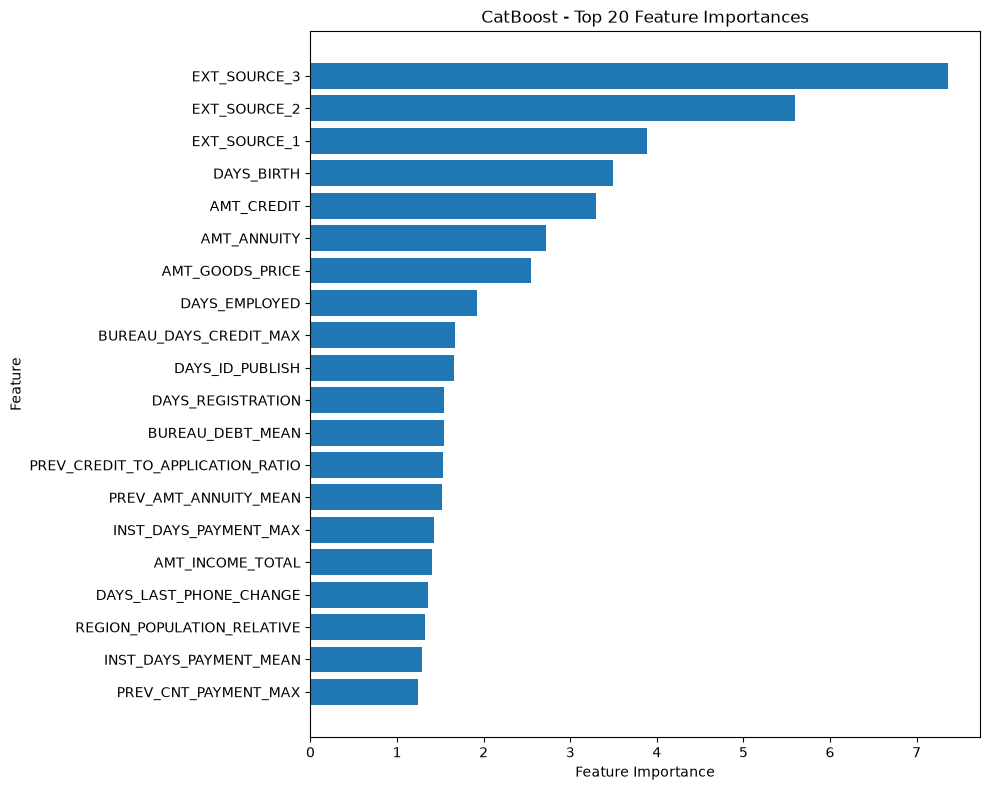

In [40]:
import matplotlib.pyplot as plt

top_features = catboost_feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("CatBoost - Top 20 Feature Importances")

plt.tight_layout()
plt.show()

In [41]:
def get_feature_source(feature):
    if feature.startswith("BUREAU_"):
        return "Bureau"
    elif feature.startswith("PREV_"):
        return "Previous Application"
    elif feature.startswith("INST_"):
        return "Installments"
    else:
        return "Application"

feature_source_importance = (
    catboost_feature_importance
    .assign(
        source=lambda df:
        df["feature"].apply(get_feature_source)
    )
    .groupby(
        "source",
        as_index=False
    )["importance"]
    .sum()
    .sort_values(
        "importance",
        ascending=False
    )
)

feature_source_importance["importance_pct"] = (
    feature_source_importance["importance"]
    / feature_source_importance["importance"].sum()
    * 100
)

feature_source_importance

,source,importance,importance_pct
0,Application,58.182442,58.182442
2,Installments,15.354807,15.354807
3,Previous Application,15.016738,15.016738
1,Bureau,11.446012,11.446012


In [42]:
source_importance_path = (
    REPORTS_DIR / "catboost_feature_source_importance.csv"
)

feature_source_importance.to_csv(
    source_importance_path,
    index=False
)

print(f"Saved: {source_importance_path}")

Saved: c:\Projects\creditlens-ai\reports\catboost_feature_source_importance.csv


In [43]:
from catboost import Pool

SHAP_SAMPLE_SIZE = 5000

X_shap = X_val_cat.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=42
)

y_shap = y_val.loc[X_shap.index]

shap_pool = Pool(
    X_shap,
    y_shap,
    cat_features=categorical_columns
)

print(f"SHAP sample shape: {X_shap.shape}")

SHAP sample shape: (5000, 195)


In [44]:
start_time = time.time()

shap_values = catboost_model.get_feature_importance(
    shap_pool,
    type="ShapValues"
)

shap_time = time.time() - start_time

print(f"SHAP values shape: {shap_values.shape}")
print(f"SHAP calculation time: {shap_time:.2f} seconds")

SHAP values shape: (5000, 196)
SHAP calculation time: 1.94 seconds


In [45]:
shap_feature_values = shap_values[:, :-1]

shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(
        shap_feature_values
    ).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance.head(25)

,feature,mean_abs_shap
0,EXT_SOURCE_2,0.316298
1,EXT_SOURCE_3,0.281433
2,EXT_SOURCE_1,0.182193
3,AMT_GOODS_PRICE,0.158791
4,AMT_CREDIT,0.153574
5,CODE_GENDER,0.133754
6,DAYS_EMPLOYED,0.122708
7,AMT_ANNUITY,0.104602
8,DAYS_BIRTH,0.096920
9,PREV_CNT_PAYMENT_MAX,0.094580


In [46]:
importance_comparison = (
    catboost_feature_importance
    .merge(
        shap_importance,
        on="feature",
        how="inner"
    )
)

importance_comparison["catboost_rank"] = (
    importance_comparison["importance"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

importance_comparison["shap_rank"] = (
    importance_comparison["mean_abs_shap"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

importance_comparison = (
    importance_comparison
    .sort_values("shap_rank")
    .reset_index(drop=True)
)

importance_comparison.head(25)

,feature,importance,mean_abs_shap,catboost_rank,shap_rank
0,EXT_SOURCE_2,5.592724,0.316298,2,1
1,EXT_SOURCE_3,7.364126,0.281433,1,2
2,EXT_SOURCE_1,3.886209,0.182193,3,3
3,AMT_GOODS_PRICE,2.547769,0.158791,7,4
4,AMT_CREDIT,3.299546,0.153574,5,5
5,CODE_GENDER,1.184740,0.133754,23,6
6,DAYS_EMPLOYED,1.926013,0.122708,8,7
7,AMT_ANNUITY,2.717793,0.104602,6,8
8,DAYS_BIRTH,3.499162,0.096920,4,9
9,PREV_CNT_PAYMENT_MAX,1.243701,0.094580,20,10


In [47]:
shap_importance_path = (
    REPORTS_DIR / "catboost_shap_importance.csv"
)

shap_importance.to_csv(
    shap_importance_path,
    index=False
)

importance_comparison_path = (
    REPORTS_DIR /
    "catboost_importance_comparison.csv"
)

importance_comparison.to_csv(
    importance_comparison_path,
    index=False
)

print(f"Saved: {shap_importance_path}")
print(f"Saved: {importance_comparison_path}")

Saved: c:\Projects\creditlens-ai\reports\catboost_shap_importance.csv
Saved: c:\Projects\creditlens-ai\reports\catboost_importance_comparison.csv


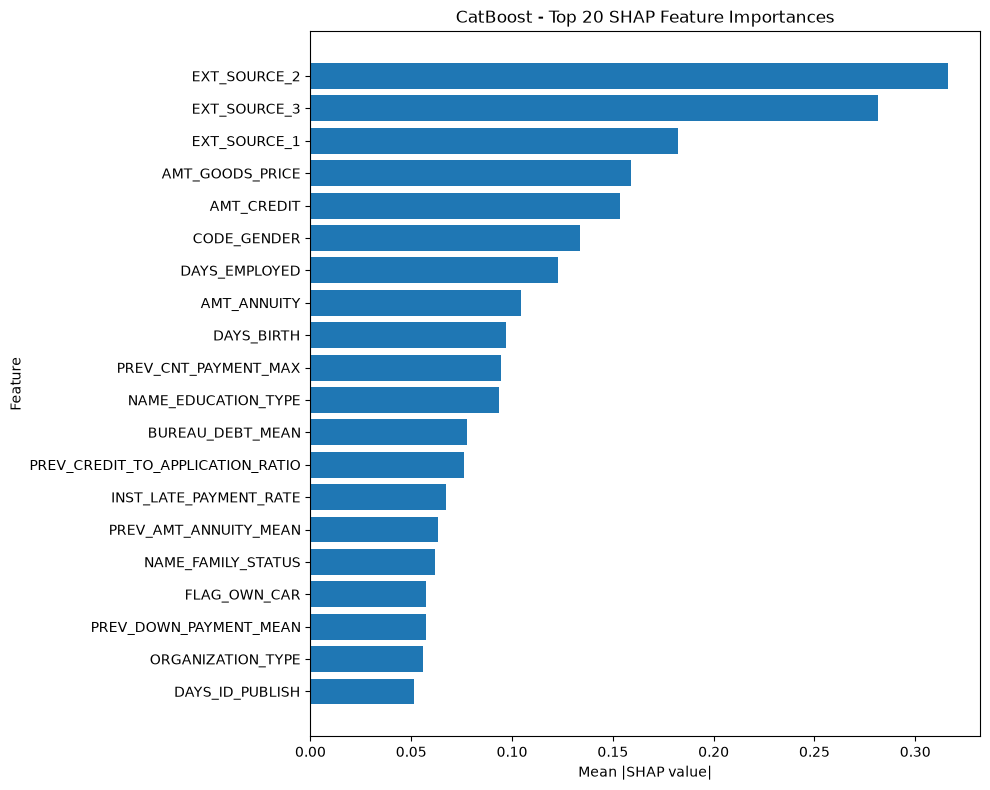

In [48]:
top_shap_features = shap_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_shap_features["feature"][::-1],
    top_shap_features["mean_abs_shap"][::-1]
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title("CatBoost - Top 20 SHAP Feature Importances")

plt.tight_layout()
plt.show()

In [49]:
shap_analysis_df = X_shap.copy()

for i, feature in enumerate(X_shap.columns):
    shap_analysis_df[f"SHAP__{feature}"] = (
        shap_feature_values[:, i]
    )

print(f"SHAP analysis shape: {shap_analysis_df.shape}")

SHAP analysis shape: (5000, 390)


C:\Users\Vıctus\AppData\Local\Temp\ipykernel_3444\1633012148.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  shap_analysis_df[f"SHAP__{feature}"] = (


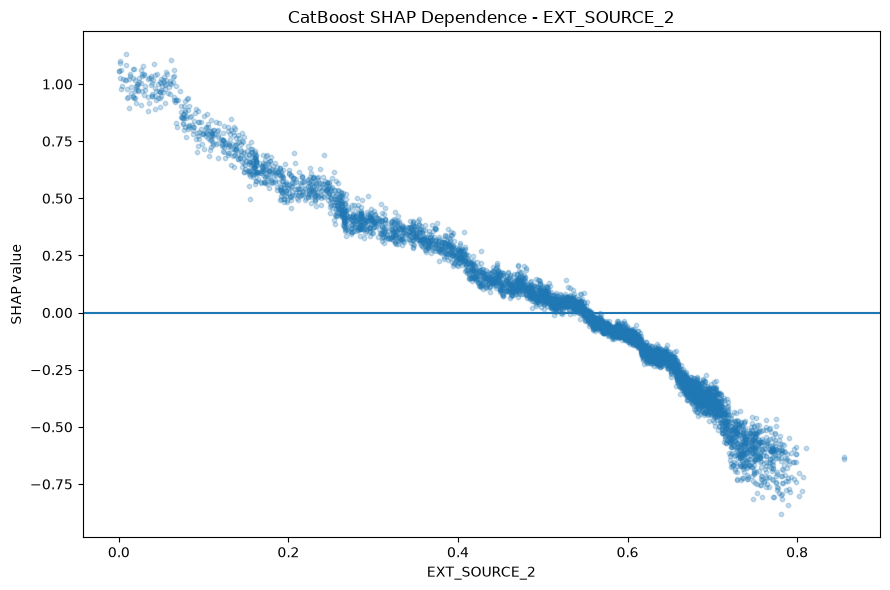

In [50]:
feature = "EXT_SOURCE_2"

valid_mask = X_shap[feature].notna()

plt.figure(figsize=(9, 6))

plt.scatter(
    X_shap.loc[valid_mask, feature],
    shap_feature_values[
        valid_mask.values,
        X_shap.columns.get_loc(feature)
    ],
    alpha=0.25,
    s=10
)

plt.axhline(0)

plt.xlabel(feature)
plt.ylabel("SHAP value")
plt.title(
    f"CatBoost SHAP Dependence - {feature}"
)

plt.tight_layout()
plt.show()

In [51]:
direction_features = [
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "EXT_SOURCE_1",
    "BUREAU_DEBT_MEAN",
    "PREV_CREDIT_TO_APPLICATION_RATIO",
    "INST_LATE_PAYMENT_RATE",
    "INST_DPD_MEAN"
]

direction_results = []

for feature in direction_features:

    feature_index = X_shap.columns.get_loc(
        feature
    )

    values = pd.to_numeric(
        X_shap[feature],
        errors="coerce"
    )

    shap_vals = shap_feature_values[
        :,
        feature_index
    ]

    valid = values.notna()

    correlation = np.corrcoef(
        values[valid],
        shap_vals[valid]
    )[0, 1]

    direction_results.append({
        "feature": feature,
        "value_shap_correlation": correlation,
        "mean_abs_shap": np.abs(
            shap_vals
        ).mean()
    })

direction_results = pd.DataFrame(
    direction_results
).sort_values(
    "mean_abs_shap",
    ascending=False
)

direction_results

,feature,value_shap_correlation,mean_abs_shap
0,EXT_SOURCE_2,-0.982915,0.316298
1,EXT_SOURCE_3,-0.978508,0.281433
2,EXT_SOURCE_1,-0.968679,0.182193
3,BUREAU_DEBT_MEAN,0.269433,0.077477
4,PREV_CREDIT_TO_APPLICATION_RATIO,0.271601,0.076217
5,INST_LATE_PAYMENT_RATE,0.861958,0.067313
6,INST_DPD_MEAN,0.216939,0.043027


In [52]:
direction_report_path = (
    REPORTS_DIR / "catboost_shap_direction_summary.csv"
)

direction_results.to_csv(
    direction_report_path,
    index=False
)

print(f"Saved: {direction_report_path}")

Saved: c:\Projects\creditlens-ai\reports\catboost_shap_direction_summary.csv


In [53]:
ablation_drop_features = [
    "CODE_GENDER"
]

X_train_no_gender = X_train_cat.drop(
    columns=ablation_drop_features
).copy()

X_val_no_gender = X_val_cat.drop(
    columns=ablation_drop_features
).copy()

categorical_columns_no_gender = [
    column
    for column in categorical_columns
    if column not in ablation_drop_features
]

print(f"Original features: {X_train_cat.shape[1]}")
print(f"Ablation features: {X_train_no_gender.shape[1]}")
print(
    f"Categorical features: "
    f"{len(categorical_columns_no_gender)}"
)

Original features: 195
Ablation features: 194
Categorical features: 15


In [54]:
catboost_no_gender = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",

    iterations=1525,
    learning_rate=0.03,
    depth=7,

    l2_leaf_reg=5,

    auto_class_weights="Balanced",

    random_seed=42,
    thread_count=-1,

    verbose=200,
    allow_writing_files=False
)

start_time = time.time()

catboost_no_gender.fit(
    X_train_no_gender,
    y_train,

    cat_features=categorical_columns_no_gender,

    eval_set=(
        X_val_no_gender,
        y_val
    ),

    use_best_model=False
)

no_gender_training_time = (
    time.time() - start_time
)

print(
    f"Training time: "
    f"{no_gender_training_time:.2f} seconds"
)

0:	test: 0.7025961	best: 0.7025961 (0)	total: 217ms	remaining: 5m 30s
200:	test: 0.7646964	best: 0.7646964 (200)	total: 45.6s	remaining: 5m
400:	test: 0.7720646	best: 0.7720646 (400)	total: 1m 25s	remaining: 3m 59s
600:	test: 0.7774986	best: 0.7774986 (600)	total: 2m 7s	remaining: 3m 15s
800:	test: 0.7798276	best: 0.7798276 (800)	total: 2m 48s	remaining: 2m 32s
1000:	test: 0.7811205	best: 0.7811205 (1000)	total: 3m 30s	remaining: 1m 49s
1200:	test: 0.7817073	best: 0.7817611 (1154)	total: 4m 15s	remaining: 1m 8s
1400:	test: 0.7820283	best: 0.7820753 (1388)	total: 5m	remaining: 26.6s
1524:	test: 0.7820019	best: 0.7820849 (1469)	total: 5m 26s	remaining: 0us

bestTest = 0.7820849131
bestIteration = 1469

Training time: 327.58 seconds


In [55]:
no_gender_probabilities = (
    catboost_no_gender.predict_proba(
        X_val_no_gender
    )[:, 1]
)

no_gender_predictions = (
    no_gender_probabilities >= 0.50
).astype(int)

no_gender_metrics = {
    "accuracy": accuracy_score(
        y_val,
        no_gender_predictions
    ),
    "precision": precision_score(
        y_val,
        no_gender_predictions,
        zero_division=0
    ),
    "recall": recall_score(
        y_val,
        no_gender_predictions,
        zero_division=0
    ),
    "f1": f1_score(
        y_val,
        no_gender_predictions,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_val,
        no_gender_probabilities
    ),
    "pr_auc": average_precision_score(
        y_val,
        no_gender_probabilities
    )
}

fairness_ablation_comparison = pd.DataFrame({
    "CatBoost_Full": catboost_metrics,
    "CatBoost_Without_CODE_GENDER": no_gender_metrics
}).T

fairness_ablation_comparison

,accuracy,precision,recall,f1,roc_auc,pr_auc
CatBoost_Full,0.759378,0.198307,0.650957,0.304002,0.784186,0.282759
CatBoost_Without_CODE_GENDER,0.758418,0.196664,0.645921,0.301523,0.782002,0.279426


In [56]:
best_no_gender_iteration = (
    catboost_no_gender.get_best_iteration()
)

catboost_no_gender_best = (
    catboost_no_gender.copy()
)

catboost_no_gender_best.shrink(
    ntree_end=best_no_gender_iteration + 1
)

print(
    f"Best no-gender iteration: "
    f"{best_no_gender_iteration}"
)

print(
    f"Trees after shrink: "
    f"{catboost_no_gender_best.tree_count_}"
)

Best no-gender iteration: 1469
Trees after shrink: 1470


In [57]:
no_gender_best_probabilities = (
    catboost_no_gender_best.predict_proba(
        X_val_no_gender
    )[:, 1]
)

no_gender_best_predictions = (
    no_gender_best_probabilities >= 0.50
).astype(int)

no_gender_best_metrics = {
    "accuracy": accuracy_score(
        y_val,
        no_gender_best_predictions
    ),
    "precision": precision_score(
        y_val,
        no_gender_best_predictions,
        zero_division=0
    ),
    "recall": recall_score(
        y_val,
        no_gender_best_predictions,
        zero_division=0
    ),
    "f1": f1_score(
        y_val,
        no_gender_best_predictions,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_val,
        no_gender_best_probabilities
    ),
    "pr_auc": average_precision_score(
        y_val,
        no_gender_best_probabilities
    )
}

final_ablation_comparison = pd.DataFrame({
    "CatBoost_Full": catboost_metrics,
    "CatBoost_Without_CODE_GENDER": (
        no_gender_best_metrics
    )
}).T

final_ablation_comparison

,accuracy,precision,recall,f1,roc_auc,pr_auc
CatBoost_Full,0.759378,0.198307,0.650957,0.304002,0.784186,0.282759
CatBoost_Without_CODE_GENDER,0.756874,0.196155,0.649345,0.301294,0.782085,0.279699


In [58]:
ablation_delta = pd.DataFrame({
    "full_model": pd.Series(catboost_metrics),
    "without_gender": pd.Series(
        no_gender_best_metrics
    )
})

ablation_delta["absolute_change"] = (
    ablation_delta["without_gender"]
    - ablation_delta["full_model"]
)

ablation_delta

,full_model,without_gender,absolute_change
accuracy,0.759378,0.756874,-0.002504
precision,0.198307,0.196155,-0.002152
recall,0.650957,0.649345,-0.001611
f1,0.304002,0.301294,-0.002708
roc_auc,0.784186,0.782085,-0.002101
pr_auc,0.282759,0.279699,-0.003060


In [59]:
fairness_ablation_path = (
    REPORTS_DIR /
    "catboost_gender_ablation_comparison.csv"
)

final_ablation_comparison.to_csv(
    fairness_ablation_path,
    index=True
)

print(f"Saved: {fairness_ablation_path}")

Saved: c:\Projects\creditlens-ai\reports\catboost_gender_ablation_comparison.csv


In [60]:
fairness_audit_df = pd.DataFrame({
    "y_true": y_val,
    "probability": no_gender_best_probabilities,
    "prediction": no_gender_best_predictions,
    "CODE_GENDER": X_val["CODE_GENDER"].astype(str)
})

fairness_audit_df.head()

,y_true,probability,prediction,CODE_GENDER
256571,0,0.309908,0,M
191493,0,0.315147,0,F
103497,0,0.637288,1,M
130646,0,0.444116,0,F
211898,0,0.608039,1,F


In [61]:
gender_fairness_results = []

for gender, group in fairness_audit_df.groupby("CODE_GENDER"):

    y_true_group = group["y_true"]
    y_pred_group = group["prediction"]
    y_prob_group = group["probability"]

    tn, fp, fn, tp = confusion_matrix(
        y_true_group,
        y_pred_group,
        labels=[0, 1]
    ).ravel()

    gender_fairness_results.append({
        "group": gender,
        "n": len(group),

        "positive_rate_actual": y_true_group.mean(),

        "selection_rate": y_pred_group.mean(),

        "accuracy": accuracy_score(
            y_true_group,
            y_pred_group
        ),

        "precision": precision_score(
            y_true_group,
            y_pred_group,
            zero_division=0
        ),

        "recall_tpr": recall_score(
            y_true_group,
            y_pred_group,
            zero_division=0
        ),

        "fpr": (
            fp / (fp + tn)
            if (fp + tn) > 0
            else np.nan
        ),

        "fnr": (
            fn / (fn + tp)
            if (fn + tp) > 0
            else np.nan
        ),

        "roc_auc": (
            roc_auc_score(
                y_true_group,
                y_prob_group
            )
            if y_true_group.nunique() == 2
            else np.nan
        ),

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

gender_fairness_results = pd.DataFrame(
    gender_fairness_results
)

gender_fairness_results

,group,n,positive_rate_actual,selection_rate,accuracy,precision,recall_tpr,fpr,fnr,roc_auc,TN,FP,FN,TP
0,F,40561,0.069919,0.238973,0.777791,0.181368,0.619887,0.210338,0.380113,0.776774,29790,7935,1078,1758
1,M,20940,0.101671,0.321968,0.716380,0.217443,0.688586,0.280474,0.311414,0.781438,13535,5276,663,1466
2,XNA,2,0.000000,0.500000,0.500000,0.000000,0.000000,0.500000,NaN,NaN,1,1,0,0


In [62]:
fairness_gap_metrics = [
    "selection_rate",
    "recall_tpr",
    "fpr",
    "fnr",
    "roc_auc"
]

fairness_gaps = []

for metric in fairness_gap_metrics:

    valid_values = (
        gender_fairness_results[metric]
        .dropna()
    )

    fairness_gaps.append({
        "metric": metric,
        "min": valid_values.min(),
        "max": valid_values.max(),
        "absolute_gap": (
            valid_values.max()
            - valid_values.min()
        )
    })

fairness_gap_results = pd.DataFrame(
    fairness_gaps
)

fairness_gap_results

,metric,min,max,absolute_gap
0,selection_rate,0.238973,0.500000,0.261027
1,recall_tpr,0.000000,0.688586,0.688586
2,fpr,0.210338,0.500000,0.289662
3,fnr,0.311414,0.380113,0.068699
4,roc_auc,0.776774,0.781438,0.004664


In [63]:
gender_fairness_path = (
    REPORTS_DIR /
    "catboost_gender_fairness_audit.csv"
)

gender_fairness_results.to_csv(
    gender_fairness_path,
    index=False
)

fairness_gap_path = (
    REPORTS_DIR /
    "catboost_gender_fairness_gaps.csv"
)

fairness_gap_results.to_csv(
    fairness_gap_path,
    index=False
)

print(f"Saved: {gender_fairness_path}")
print(f"Saved: {fairness_gap_path}")

Saved: c:\Projects\creditlens-ai\reports\catboost_gender_fairness_audit.csv
Saved: c:\Projects\creditlens-ai\reports\catboost_gender_fairness_gaps.csv


In [64]:
MIN_GROUP_SIZE = 100

gender_fairness_major_groups = (
    gender_fairness_results[
        gender_fairness_results["n"] >= MIN_GROUP_SIZE
    ]
    .copy()
    .reset_index(drop=True)
)

gender_fairness_major_groups

,group,n,positive_rate_actual,selection_rate,accuracy,precision,recall_tpr,fpr,fnr,roc_auc,TN,FP,FN,TP
0,F,40561,0.069919,0.238973,0.777791,0.181368,0.619887,0.210338,0.380113,0.776774,29790,7935,1078,1758
1,M,20940,0.101671,0.321968,0.716380,0.217443,0.688586,0.280474,0.311414,0.781438,13535,5276,663,1466


In [65]:
fairness_gap_metrics = [
    "positive_rate_actual",
    "selection_rate",
    "precision",
    "recall_tpr",
    "fpr",
    "fnr",
    "roc_auc"
]

major_group_fairness_gaps = []

for metric in fairness_gap_metrics:

    valid_data = (
        gender_fairness_major_groups[
            ["group", metric]
        ]
        .dropna()
    )

    min_row = valid_data.loc[
        valid_data[metric].idxmin()
    ]

    max_row = valid_data.loc[
        valid_data[metric].idxmax()
    ]

    major_group_fairness_gaps.append({
        "metric": metric,
        "min_group": min_row["group"],
        "min_value": min_row[metric],
        "max_group": max_row["group"],
        "max_value": max_row[metric],
        "absolute_gap": (
            max_row[metric]
            - min_row[metric]
        )
    })

major_group_fairness_gaps = pd.DataFrame(
    major_group_fairness_gaps
)

major_group_fairness_gaps

,metric,min_group,min_value,max_group,max_value,absolute_gap
0,positive_rate_actual,F,0.069919,M,0.101671,0.031752
1,selection_rate,F,0.238973,M,0.321968,0.082994
2,precision,F,0.181368,M,0.217443,0.036075
3,recall_tpr,F,0.619887,M,0.688586,0.068699
4,fpr,F,0.210338,M,0.280474,0.070136
5,fnr,M,0.311414,F,0.380113,0.068699
6,roc_auc,F,0.776774,M,0.781438,0.004664


In [66]:
major_group_audit_path = (
    REPORTS_DIR /
    "catboost_gender_fairness_major_groups.csv"
)

gender_fairness_major_groups.to_csv(
    major_group_audit_path,
    index=False
)

major_group_gap_path = (
    REPORTS_DIR /
    "catboost_gender_fairness_major_group_gaps.csv"
)

major_group_fairness_gaps.to_csv(
    major_group_gap_path,
    index=False
)

print(f"Saved: {major_group_audit_path}")
print(f"Saved: {major_group_gap_path}")

Saved: c:\Projects\creditlens-ai\reports\catboost_gender_fairness_major_groups.csv
Saved: c:\Projects\creditlens-ai\reports\catboost_gender_fairness_major_group_gaps.csv


## Fairness Audit

`CODE_GENDER` was removed from the primary CatBoost research model and retained only for post-hoc fairness auditing.

Removing `CODE_GENDER` resulted in a limited reduction in development validation performance:

- ROC-AUC: 0.7842 → 0.7821
- PR-AUC: 0.2828 → 0.2797
- F1: 0.3040 → 0.3013

Performance was then evaluated across gender groups using the same 0.50 operating threshold.

The two sufficiently represented groups showed similar ranking performance, with ROC-AUC values of approximately 0.777 and 0.781. However, differences were observed in threshold-dependent error rates, including approximately 6.9 percentage points in recall and 7.0 percentage points in false-positive rate.

A very small XNA group contained only two validation observations and was retained in the raw audit output but excluded from headline gap calculations because its metrics are statistically unstable.

These results are treated as a diagnostic fairness audit rather than evidence that the model is fair or unfair. No group-specific decision thresholds are applied.

## Final Development Conclusion

Three model families were compared under the same development validation split:

| Model | ROC-AUC | PR-AUC | F1 @ 0.50 |
|---|---:|---:|---:|
| Logistic Regression | 0.7655 | 0.2473 | 0.2734 |
| LightGBM | 0.7815 | 0.2779 | 0.2970 |
| CatBoost | 0.7842 | 0.2828 | 0.3040 |

CatBoost achieved the strongest predictive performance.

A fairness-oriented ablation experiment was also performed by removing `CODE_GENDER` from the model. The gender-free CatBoost retained most of the predictive performance:

- ROC-AUC: 0.7842 → 0.7821
- PR-AUC: 0.2828 → 0.2797
- F1: 0.3040 → 0.3013

For this reason, the CatBoost model without `CODE_GENDER` is retained as the primary research candidate, while the full CatBoost model is kept as a predictive benchmark.

Post-hoc group auditing showed similar ROC-AUC across the two sufficiently represented gender groups, but threshold-dependent differences remained in recall, false-positive rate, and false-negative rate.

The model is therefore treated as a research and decision-support model rather than an autonomous lending approval system. No group-specific decision thresholds are applied.

All reported scores in this notebook are development-validation results. Final generalization performance should be estimated separately using cross-validation or an untouched holdout procedure.